<a href="https://colab.research.google.com/github/sara-sgit/Plant-Disease-Classification/blob/main/DenseNet201.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from keras.models import Sequential, load_model
from keras.layers import Dense, Dropout, Flatten , BatchNormalization
from keras.layers.convolutional import Conv2D,AveragePooling2D, MaxPooling2D
from keras.utils.np_utils import to_categorical
from keras import callbacks
from keras.callbacks import ModelCheckpoint


import tensorflow as tf
import pickle as pk
import numpy as np


from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV
from keras.models import Model
from sklearn.metrics import classification_report

import tensorflow
tf.__version__
from tensorflow.compat.v1 import ConfigProto
from tensorflow.compat.v1 import InteractiveSession

config = ConfigProto()
config.gpu_options.per_process_gpu_memory_fraction = 0.95
config.gpu_options.allow_growth = True
session = InteractiveSession(config=config)
# import the libraries as shown below

from tensorflow.keras.layers import Input, Lambda, Dense, Flatten
from tensorflow.keras.models import Model
from tensorflow.keras.applications.densenet import DenseNet201
#from keras.applications.vgg16 import VGG1
from tensorflow.keras.applications.inception_v3 import preprocess_input
from tensorflow.keras.preprocessing import image
from tensorflow.keras.preprocessing.image import ImageDataGenerator,load_img
from tensorflow.keras.models import Sequential
import numpy as np
from glob import glob
#import matplotlib.pyplot as plt

In [ ]:
# Define the desired height and width for all images
H=224
W=224
# Set the target image size as a list [height, width]
IMAGE_SIZE = [H, W]

# Define the path to the training dataset
train_path = '/content/drive/MyDrive/DATA1/train'
# Define the path to the validation (test) dataset
valid_path = '/content/drive/MyDrive/DATA1/test'




In [ ]:

# Import the DenseNet201 model with pre-trained ImageNet weights.
# We set include_top=False to remove the final classification layer,
# as we'll add our own classifier later.
densenet = DenseNet201(input_shape=IMAGE_SIZE + [3], weights='imagenet', include_top=False)

# Freeze all layers in the DenseNet model to retain pre-trained weights.
# This prevents them from being updated during training.
for layer in densenet.layers:
    layer.trainable = False

74836368/74836368 [==============================] - 0s 0us/step


In [ ]:
# Get the list of folders (one per class) in the training directory.
# This helps determine the number of output classes dynamically.
folders = glob(train_path+'/*')

# Add custom layers on top of the DenseNet base.
# Flatten the output of DenseNet to prepare it for the dense layers.
x = Flatten()(densenet.output)
# Add a fully connected (dense) layer with 4096 units.
# We use the LeakyReLU activation function to avoid the "dying ReLU" problem.
x = Dense(4096, activation='LeakyReLU', name='fc1')(x)
# Optionally, you can add another dense layer (currently commented out).
# x = Dense(4096, activation='relu', name='fc2')(x)

# Add the final output layer with softmax activation.
# The number of units equals the number of classes (based on the folders).
prediction = Dense(len(folders), activation='softmax', name='predictions')(x)

In [ ]:
folders

[]

In [ ]:

# Create the model by specifying the inputs and outputs.
# The input is from the DenseNet base, and the output is from the custom prediction layer.
model = Model(inputs=densenet.input, outputs=prediction)

# Display the model summary to view its architecture and number of parameters.
model.summary()

# Compile the model by specifying the loss function, optimizer, and evaluation metric.
# We use categorical crossentropy for multi-class classification.
# Stochastic Gradient Descent (SGD) is the optimizer, and accuracy is the metric.
model.compile(
  loss='categorical_crossentropy',
  optimizer='SGD',
  metrics=['accuracy']
)

Model: "model"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_1 (InputLayer)           [(None, 224, 224, 3  0           []                               
                                )]                                                                
                                                                                                  
 zero_padding2d (ZeroPadding2D)  (None, 230, 230, 3)  0          ['input_1[0][0]']                
                                                                                                  
 conv1/conv (Conv2D)            (None, 112, 112, 64  9408        ['zero_padding2d[0][0]']         
                                )                                                                 
                                                                                              

In [ ]:
# Import ImageDataGenerator to help with real-time image augmentation and loading
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Define batch size and target size for images (height, width)
batch_size=16
target_size=(H,W)

# Set up the image data generator for the training set with specific augmentation techniques.
# Here, only rescaling is used (no other augmentations like shear, zoom, or flip).
train_datagen = ImageDataGenerator(rescale = 1./255,
                                   shear_range = 0,
                                   zoom_range = 0,
                                   horizontal_flip = False)

# Set up the image data generator for the test/validation set with rescaling.
# The validation data doesn't need augmentations like the training set.


test_datagen = ImageDataGenerator(rescale = 1./255,shear_range = 0,
                                   zoom_range = 0,
                                   horizontal_flip = False)
# Generate batches of data from the training directory using the ImageDataGenerator.
# `class_mode='categorical'` is used because it's a multi-class classification problem.
training_set = train_datagen.flow_from_directory(train_path,
                                                 target_size = target_size,
                                                 batch_size = batch_size,
                                                 class_mode = 'categorical')

# Generate batches of data from the validation directory using the ImageDataGenerator.
# `shuffle=False` ensures the data is not shuffled, which is often done during validation/testing.
test_set = test_datagen.flow_from_directory(valid_path,
                                            target_size = target_size,
                                            batch_size = batch_size,
                                            shuffle=False,
                                            class_mode = 'categorical')

Found 12811 images belonging to 10 classes.
Found 3200 images belonging to 10 classes.


In [ ]:
# Define the number of epochs for training
Epoch=50
# Specify the path where the best model will be saved after each training session
# The model will be saved with the number of epochs in the file name
path='/content/drive/MyDrive/Models/DenseNet_'+str(Epoch)+'e.h5'

# Set up EarlyStopping callback to stop training if the validation accuracy doesn't improve
# for 50 consecutive epochs (patience=50). It will restore the model weights
# to the best state observed during training.
es = callbacks.EarlyStopping(monitor='val_accuracy', mode='max', patience=50,restore_best_weights = True)

# Set up ModelCheckpoint callback to save the best model based on validation accuracy
# The best model (with the highest val_accuracy) will be saved during training
mc = ModelCheckpoint(path, monitor='val_accuracy', mode='max', verbose=1,save_best_only=True)

In [ ]:
# Train (fit) the model using the training and validation sets.
# This process might take some time depending on your hardware and dataset size.

r = model.fit(
  training_set,
  validation_data=test_set,
  epochs=Epoch,
  callbacks=[es, mc],
  steps_per_epoch=len(training_set),
  validation_steps=len(test_set)
)

Epoch 1/50
801/801 [==============================] - ETA: 0s - loss: 14.0439 - accuracy: 0.8120 
Epoch 1: val_accuracy improved from -inf to 0.88906, saving model to /content/drive/MyDrive/Models/DenseNet_50e.h5
801/801 [==============================] - 10697s 13s/step - loss: 14.0439 - accuracy: 0.8120 - val_loss: 6.1745 - val_accuracy: 0.8891
Epoch 2/50
801/801 [==============================] - ETA: 0s - loss: 8.4028 - accuracy: 0.8996
Epoch 2: val_accuracy did not improve from 0.88906
801/801 [==============================] - 140s 175ms/step - loss: 8.4028 - accuracy: 0.8996 - val_loss: 24.2560 - val_accuracy: 0.8091
Epoch 3/50
801/801 [==============================] - ETA: 0s - loss: 12.5879 - accuracy: 0.9177
Epoch 3: val_accuracy did not improve from 0.88906
801/801 [==============================] - 134s 168ms/step - loss: 12.5879 - accuracy: 0.9177 - val_loss: 31.2322 - val_accuracy: 0.8531
Epoch 4/50
801/801 [==============================] - ETA: 0s - loss: 11.8344 - acc

In [ ]:
# Save the entire model to the specified path
m=model.savdde('C:/Users/mezen/OneDrive/Desktop/DOC1/Disease Classification/vars/models/Inceptionv3/Inception100eCPD-F3.h5')

In [ ]:

# Load the saved model from the specified path

model=load_model(path)

In [ ]:
# Print the list of validation accuracy values for each epoch
print(r.history['val_accuracy'])
# Print the maximum (best) validation accuracy achieved during training

print(max(r.history['val_accuracy']))

# Get the epoch index (0-based) where the best validation accuracy occurred

I=r.history['val_accuracy'].index(max(r.history['val_accuracy']))
I

[0.8568750023841858, 0.8568750023841858, 0.8659374713897705, 0.8606250286102295, 0.8496875166893005, 0.8581249713897705, 0.8740624785423279, 0.8678125143051147, 0.8837500214576721, 0.9009374976158142, 0.909375011920929, 0.8693749904632568, 0.8918750286102295, 0.9053124785423279, 0.9103124737739563, 0.8831250071525574, 0.8793749809265137, 0.8993750214576721, 0.8881250023841858, 0.8668749928474426, 0.8821874856948853, 0.918749988079071, 0.9003124833106995, 0.8903124928474426, 0.9090625047683716, 0.9081249833106995, 0.9065625071525574, 0.901562511920929, 0.9100000262260437, 0.9125000238418579, 0.901562511920929, 0.9096875190734863, 0.9056249856948853, 0.9231250286102295, 0.9046875238418579, 0.9115625023841858, 0.9146875143051147, 0.8909375071525574, 0.8993750214576721, 0.9131249785423279, 0.9193750023841858, 0.9012500047683716, 0.9153125286102295, 0.9168750047683716, 0.9028124809265137, 0.9112499952316284, 0.9225000143051147, 0.9096875190734863, 0.9059374928474426, 0.9078124761581421, 0.9

195

In [ ]:
# Predict class probabilities for the test set
y_predrob = model.predict(test_set)
# Convert probabilities to class labels (the index of the highest probability)

import numpy as np
y_pred = np.argmax(y_predrob, axis=1)
# Get the true labels from the test set
labels=test_set.labels
# Calculate accuracy: (number of correct predictions) / (total number of samples)
sum((labels==y_pred)*1)/len(y_pred)


200/200 [==============================] - 6s 29ms/step


0.9334375

In [ ]:
len(labels)

3200

In [ ]:
y_pred


array([0, 0, 0, ..., 9, 9, 9], dtype=int64)

In [ ]:
# Import necessary tools for evaluation
from sklearn.metrics import classification_report ,confusion_matrix,ConfusionMatrixDisplay
# Generate a confusion matrix
# 'normalize="true"' normalizes each row (i.e., shows the proportion of true labels that were correctly predicted)


confusion_matrix1= confusion_matrix(labels, y_pred,normalize='true')

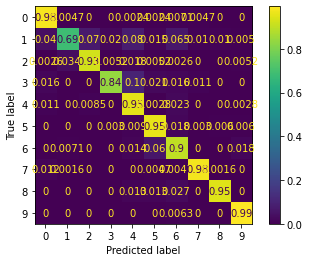

In [ ]:
# Create a ConfusionMatrixDisplay object using the confusion matrix

cm_display = ConfusionMatrixDisplay(confusion_matrix = confusion_matrix1)
# Import matplotlib for plotting
import matplotlib.pyplot as plt
# Plot the confusion matrix
cm_display.plot()

# Show the plot
plt.show()


In [ ]:
y_predrob = model.predict(training_set)

import numpy as np
y_pred = np.argmax(y_predrob, axis=1)

labels=training_set.labels
sum((labels==y_pred)*1)/len(y_pred)

In [ ]:
from sklearn.metrics import classification_report ,confusion_matrix,ConfusionMatrixDisplay

confusion_matrix1= confusion_matrix(labels, y_pred,normalize='true')

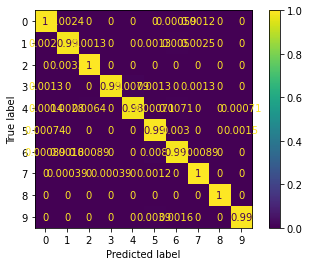

In [ ]:
cm_display = ConfusionMatrixDisplay(confusion_matrix = confusion_matrix1)

import matplotlib.pyplot as plt

cm_display.plot()
plt.show()


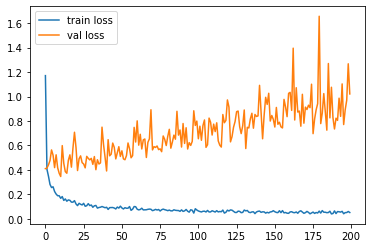

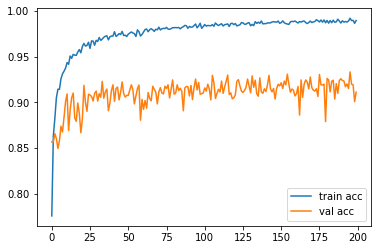

<Figure size 432x288 with 0 Axes>

In [ ]:
import matplotlib.pyplot as plt

# plot the loss
plt.plot(r.history['loss'], label='train loss')
plt.plot(r.history['val_loss'], label='val loss')
plt.legend()
plt.show()
plt.savefig('LossVal_loss')

# plot the accuracy
plt.plot(r.history['accuracy'], label='train acc')
plt.plot(r.history['val_accuracy'], label='val acc')
plt.legend()
plt.show()
plt.savefig('AccVal_acc')

In [ ]:
len(training_set[799][0])

16

In [ ]:
# Get a dictionary mapping class labels (folder names) to numerical indices
test_set.class_indices

{'Tomato_Bacterial_spot': 0,
 'Tomato_Early_blight': 1,
 'Tomato_Late_blight': 2,
 'Tomato_Leaf_Mold': 3,
 'Tomato_Septoria_leaf_spot': 4,
 'Tomato_Spider_mites_Two_spotted_spider_mite': 5,
 'Tomato__Target_Spot': 6,
 'Tomato__Tomato_YellowLeaf__Curl_Virus': 7,
 'Tomato__Tomato_mosaic_virus': 8,
 'Tomato_healthy': 9}

In [ ]:
pk.dump(y_pred,open('C:/Users/mezen/OneDrive/Desktop/DOC1/Disease Classification/vars/features/F3/test/y_pred_DenseNet201', 'wb'))
